# Klasyfikacja chorób serca z użyciem sieci neuronowej MLP                               
                                                                                           
  ## 1. Wprowadzenie teoretyczne                                                           
                                                                                           
  ### 1.1 Czym jest sieć feedforward (MLP)?                                                
                  
  **Wielowarstwowy perceptron (MLP, Multilayer Perceptron)** to rodzaj sztucznej sieci     
  neuronowej,
  w której informacja przepływa wyłącznie w jednym kierunku — od warstwy wejściowej,       
  przez warstwy ukryte, do warstwy wyjściowej. Nie ma pętli ani połączeń wstecznych.       
                                                                                           
  Architektura MLP składa się z:                                                           
  - **Warstwy wejściowej** — przyjmuje cechy pacjenta (13 zmiennych numerycznych)          
  - **Warstw ukrytych** — wykonują nieliniowe transformacje danych                         
  - **Warstwy wyjściowej** — produkuje prawdopodobieństwo przynależności do klasy          
                                                                                           
  Sieć feedforward różni się od sieci rekurencyjnej (RNN) tym, że każda obserwacja         
  jest przetwarzana niezależnie — nie ma pamięci o poprzednich wejściach.                  
  RNN stosuje się do sekwencji (tekst, audio), MLP do niezależnych obserwacji.             
                                                                                           
  ---                                                                                      
                                                                                           
  ### 1.2 Propagacja w przód (Forward Pass)                                                
                  
  Dla pojedynczego neuronu w warstwie $l$:                                                 
  
  $$z^{(l)} = \mathbf{W}^{(l)} \cdot \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}$$               
                  
  $$h^{(l)} = f\left(z^{(l)}\right)$$                                                      
                  
  gdzie:                                                                                   
  - $\mathbf{W}^{(l)}$ — macierz wag warstwy $l$
  - $\mathbf{b}^{(l)}$ — wektor biasów (wyraz wolny, pozwala neuronom aktywować się        
  niezależnie od wejścia)                                                                  
  - $f(\cdot)$ — funkcja aktywacji                                                         
  - $\mathbf{h}^{(0)} = \mathbf{x}$ — wektor cech wejściowych                              
                                                                                           
  Dla sieci z dwiema warstwami ukrytymi pełna propagacja wygląda następująco:              
                                                                                           
  $$\mathbf{h}^{(1)} = \text{ReLU}(\mathbf{W}^{(1)} \cdot \mathbf{x} + \mathbf{b}^{(1)})$$ 
                  
  $$\mathbf{h}^{(2)} = \text{ReLU}(\mathbf{W}^{(2)} \cdot \mathbf{h}^{(1)} +               
  \mathbf{b}^{(2)})$$
                                                                                           
  $$\hat{y} = \sigma(\mathbf{W}^{(3)} \cdot \mathbf{h}^{(2)} + \mathbf{b}^{(3)})$$         
  
  ---                                                                                      
                  
  ### 1.3 Funkcje aktywacji                                                                
  
  #### ReLU (Rectified Linear Unit) — warstwy ukryte                                       
                  
  $$f(x) = \max(0, x)$$                                                                    
                  
  ReLU zeruje wartości ujemne, zachowuje dodatnie bez zmian. Dzięki temu sieć może         
  modelować nieliniowe zależności między cechami.
                                                                                           
  **Dlaczego ReLU wypiera sigmoid w warstwach ukrytych?**                                  
  Sigmoid ma pochodną maksymalnie $0.25$ — przy wielu warstwach gradienty mnożą się przez
  wartości $< 1$ i maleją wykładniczo. To **problem zanikającego gradientu** —             
  głębsze warstwy uczą się bardzo wolno lub wcale.                                         
                                                                                           
  ReLU dla $x > 0$ ma pochodną równą $1$ — gradient przechodzi bez tłumienia.              
                                                                                           
  #### Sigmoid — warstwa wyjściowa                                                         
                  
  $$\sigma(x) = \frac{1}{1 + e^{-x}}$$

  Sigmoid mapuje dowolną liczbę rzeczywistą na przedział $(0, 1)$, co pozwala              
  interpretować wyjście jako **prawdopodobieństwo** przynależności do klasy "chory".
  Próg decyzyjny domyślnie wynosi $0.5$, ale można go zmieniać.                            
                                                                                           
  ---                                                                                      
                                                                                           
  ### 1.4 Funkcja straty — Binary Cross-Entropy                                            
  
  Do klasyfikacji binarnej używamy **Binary Cross-Entropy (BCE)**:                         
                  
  $$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \cdot \log(\hat{y}_i) + (1 - y_i)    
  \cdot \log(1 - \hat{y}_i)\right]$$
                                                                                           
  gdzie $y_i \in \{0, 1\}$ to prawdziwa etykieta, $\hat{y}_i \in (0,1)$ to przewidziane 
  prawdopodobieństwo.                                                                      
  
  **Dlaczego nie MSE?** Przy użyciu MSE z funkcją Sigmoid na wyjściu, gradienty            
  są bliskie zera gdy model jest pewny złej odpowiedzi — uczenie prawie się zatrzymuje.    
  BCE karze logarytmicznie: pewna zła odpowiedź ($\hat{y}=0.01$ gdy $y=1$) generuje        
  ogromną stratę ($-\log(0.01) \approx 4.6$), co wymusza silną korektę wag.                
                                                                                           
  ---                                                                                      
                                                                                           
  ### 1.5 Propagacja wsteczna (Backpropagation)
                                                                                           
  Po obliczeniu straty $\mathcal{L}$ liczymy gradient względem każdej wagi
  stosując **regułę łańcuchową**:                                                          
                  
  $$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \frac{\partial                
  \mathcal{L}}{\partial \mathbf{h}^{(l)}} \cdot \frac{\partial \mathbf{h}^{(l)}}{\partial  
  z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial \mathbf{W}^{(l)}}$$
                                                                                           
  Gradient "płynie wstecz" przez sieć — każda waga dostaje informację
  jak bardzo przyczyniła się do błędu. Wagi są następnie aktualizowane:                    
  
  $$\mathbf{W} \leftarrow \mathbf{W} - \eta \cdot \frac{\partial \mathcal{L}}{\partial     
  \mathbf{W}}$$                                                                            
  
  gdzie $\eta$ to **learning rate** (współczynnik uczenia).                                
                                                                                           
  ---
                                                                                           
  ### 1.6 Optymalizator Adam
                                                                                           
  Adam (Adaptive Moment Estimation) rozszerza SGD o adaptacyjny learning rate
  dla każdej wagi osobno. Zapamiętuje dwa momenty:                                         
                                                                                           
  **Moment 1. rzędu** (średnia gradientów — kierunek):
                                                                                           
  $$m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t$$
                                                                                           
  **Moment 2. rzędu** (średnia kwadratów gradientów — skala wahań):                        
  
  $$v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2$$                              
                  
  Aktualizacja wagi:                                                                       
                  
  $$\mathbf{W} \leftarrow \mathbf{W} - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + 
  \epsilon}$$                                                                              
  
  Domyślnie: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$.                     
                                                                                           
  **Intuicja:** wagi które rzadko dostają duże gradienty — uczą się szybciej
  (większy efektywny krok). Wagi które mocno oscylują — uczą się wolniej.                  
  Efekt: szybsza zbieżność i stabilniejszy trening niż SGD.                                
                                                                                           
  ---                                                                                      
                                                                                           
  ### 1.7 Hiperparametry MLPClassifier (sklearn)
                                                                                           
  | Hiperparametr | Wartość | Znaczenie |
  |---|---|---|                                                                            
  | `hidden_layer_sizes` | `(64, 32)` | Liczba neuronów w każdej warstwie ukrytej |
  | `activation` | `relu` | Funkcja aktywacji warstw ukrytych |                            
  | `solver` | `adam` | Optymalizator |                                                    
  | `max_iter` | `500` | Maksymalna liczba epok |
  | `random_state` | `42` | Ziarno losowości dla reprodukowalności |                       
                                                                                           
  Warstwa wyjściowa w `MLPClassifier` automatycznie używa Sigmoid                          
  dla klasyfikacji binarnej — nie trzeba tego konfigurować ręcznie.                        
                                                                                           
                                                              

## 2. Opis danych i uzasadnienie wyboru metryk                                           
                                                                                           
  ### 2.1 Zbiór danych                                                                     
                                                                                           
  Dane pochodzą z **UCI Machine Learning Repository — Heart Disease Dataset**.             
  Zbiór łączy dane z czterech ośrodków klinicznych:
  Cleveland, Hungary, VA Long Beach i Switzerland (łącznie 920 pacjentów).                 
                                                                                           
  Zmienna docelowa (`target`) jest binarna:                                                
  - **0** — brak choroby wieńcowej                                                         
  - **1** — obecność choroby wieńcowej (wartość `num > 0` w oryginale)                     
                                                                                           
  Rozkład klas: 411 zdrowych (44.7%) / 509 chorych (55.3%) — zbiór w miarę zbalansowany.   
                                                                                           
  ### 2.2 Opis cech                                                                        
                  
  | Cecha | Typ | Opis |                                                                   
  |---|---|---|
  | `age` | ciągła | Wiek pacjenta (lata) |                                                
  | `sex` | binarna | Płeć (1 = mężczyzna, 0 = kobieta) |                                  
  | `cp` | kategoryczna | Typ bólu w klatce piersiowej (1–4) |                             
  | `trestbps` | ciągła | Ciśnienie krwi w spoczynku (mm Hg) |                             
  | `chol` | ciągła | Cholesterol w surowicy (mg/dl) |                                     
  | `fbs` | binarna | Cukier na czczo > 120 mg/dl (1 = tak) |                              
  | `restecg` | kategoryczna | Wynik EKG w spoczynku (0–2) |                               
  | `thalach` | ciągła | Maksymalne osiągnięte tętno |                                     
  | `exang` | binarna | Dławica wywołana wysiłkiem (1 = tak) |                             
  | `oldpeak` | ciągła | Obniżenie ST wywołane wysiłkiem |                                 
  | `slope` | kategoryczna | Nachylenie szczytu ST (1–3) |                                 
  | `ca` | ciągła | Liczba głównych naczyń (0–3) |                                         
  | `thal` | kategoryczna | Wynik testu talowego (1–3) |                                   
                                                                                           
  ### 2.3 Braki danych                                                                     
                                                                                           
  Zbiór zawiera znaczną liczbę brakujących wartości — szczególnie w cechach                
  pochodzących z ośrodków innych niż Cleveland:
                                                                                           
  | Cecha | Braki | % |                                                                    
  |---|---|---|
  | `ca` | 611 | 66% |                                                                     
  | `thal` | 486 | 53% |
  | `slope` | 309 | 34% |                                                                  
  | `oldpeak` | 62 | 7% |
                                                                                           
  Braki uzupełniane są **medianą** kolumny obliczoną wyłącznie na zbiorze treningowym      
  (zapobieganie data leakage). Mediana jest odporna na wartości odstające,                 
  które mogą występować w danych klinicznych.                                              
                                                                                           
  ### 2.4 Uzasadnienie wyboru metryk                                                       
                                                                                           
  W diagnostyce medycznej nie wszystkie błędy są równoważne:                               
  
  - **FP** (zdrowy → chory): pacjent trafi na dodatkowe badania. Koszt: stres i czas.      
  - **FN** (chory → zdrowy): choroba pozostaje niezdiagnozowana. Koszt: zagrożenie życia.
                                                                                           
  Z tego powodu priorytetową metryką jest **Recall**:                                      
                                                                                           
  $$\mathrm{Recall} = \frac{TP}{TP + FN}$$                                                 
                  
  Recall mierzy jaki odsetek wszystkich chorych pacjentów model poprawnie wykrył.          
  Minimalizujemy FN nawet kosztem większej liczby FP.
                                                                                           
  Pozostałe metryki jako kontekst:
                                                                                           
  $$\mathrm{Precision} = \frac{TP}{TP + FP}$$                                              
  
  $$\mathrm{F1} = \frac{2 \cdot \mathrm{Precision} \cdot                                   
  \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}$$
                                                                                           
  **AUC-ROC** mierzy zdolność modelu do rozróżnienia klas niezależnie od progu             
  decyzyjnego. AUC = 0.5 oznacza losowy klasyfikator, AUC = 1.0 to ideał.



In [1]:
import sys
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns   

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score,learning_curve
from sklearn.metrics import classification_report

sys.path.append("..")
from src.data_loader import load_data
from src.preprocessing import preprocess
from src.evaluate import evaluate_model,save_metrics
from src.visualize import (
    plot_correlation_heatmap,
    plot_class_distribution,
    plot_feature_distributions,
    plot_scatter_age_thalach,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_architecture_comparison
)

df = load_data("data/heart_disease_uci.csv")

print(f"Ksztalt zbioru: {df.shape}")

print(f"\nPierwsze wiersze: {df.head()}")

print(f"\nStatystyki opisowe: ")
display(df.describe())

print(f"\nBraki Danych:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
display(pd.DataFrame({"Braki":missing,"%":missing_pct})[missing > 0])


Ksztalt zbioru: (920, 14)

Pierwsze wiersze:    age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   63    1   1     145.0  233.0  1.0      1.0    150.0    0.0      2.3   
1   67    1   4     160.0  286.0  0.0      1.0    108.0    1.0      1.5   
2   67    1   4     120.0  229.0  0.0      1.0    129.0    1.0      2.6   
3   37    1   3     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4   41    0   2     130.0  204.0  0.0      1.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   2.0       0  
1    2.0  3.0   1.0       1  
2    2.0  2.0   3.0       1  
3    3.0  0.0   1.0       0  
4    1.0  0.0   1.0       0  

Statystyki opisowe: 


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.594771,137.545665,0.389595,0.878788,1.770867,0.676375,1.990783,0.553261
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.794786,25.926276,0.487941,1.091226,0.619256,0.935653,0.946567,0.497426
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,1.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,3.000000,1.000000



Braki Danych:


,Braki,%
trestbps,59,6.4
chol,30,3.3
fbs,90,9.8
restecg,2,0.2
thalach,55,6.0
exang,55,6.0
oldpeak,62,6.7
slope,309,33.6
ca,611,66.4
thal,486,52.8


In [2]:
print(os.getcwd())

/home/zmichal/PROJECTS/SI_P/heart-disease-mlp


=== 1. MACIERZ KORELACJI ===


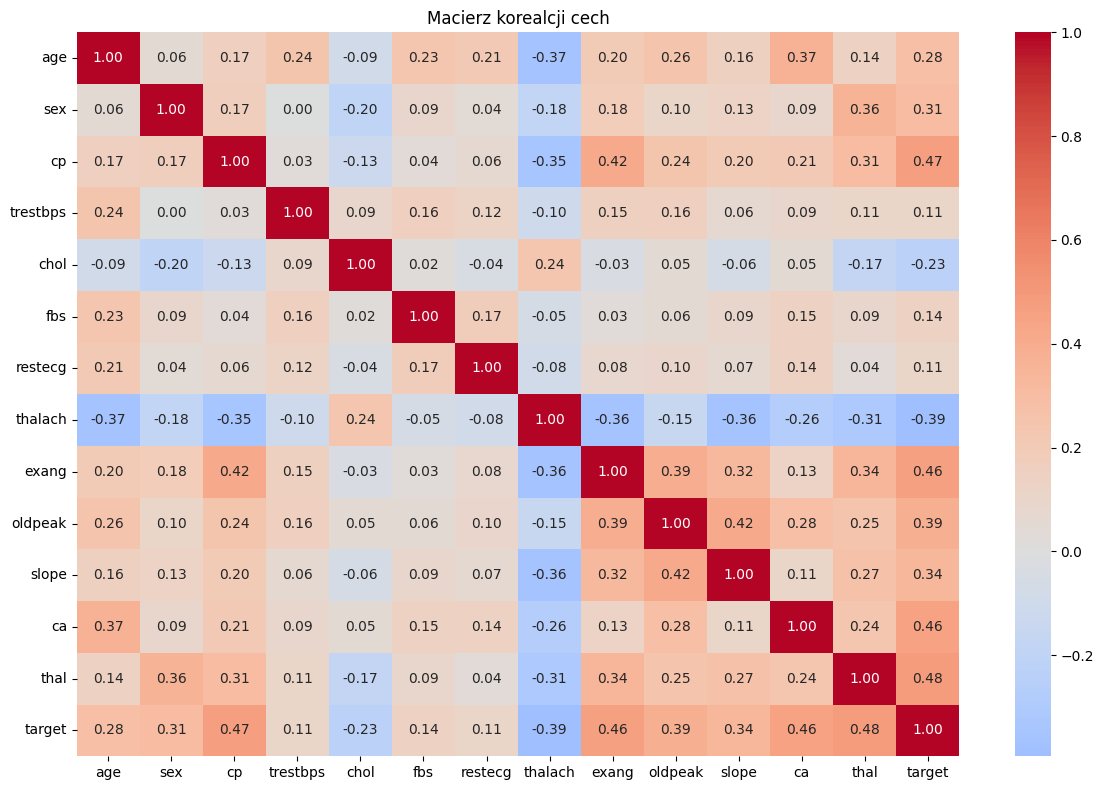

=== 2. ROZKLAD KLAS ===


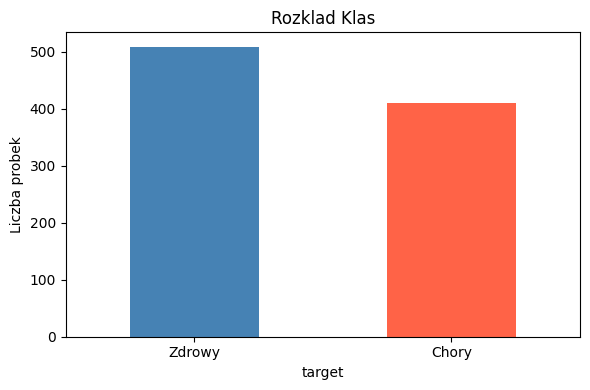

=== 3. ROZKLAD CECH WEDLUG KLAS ===


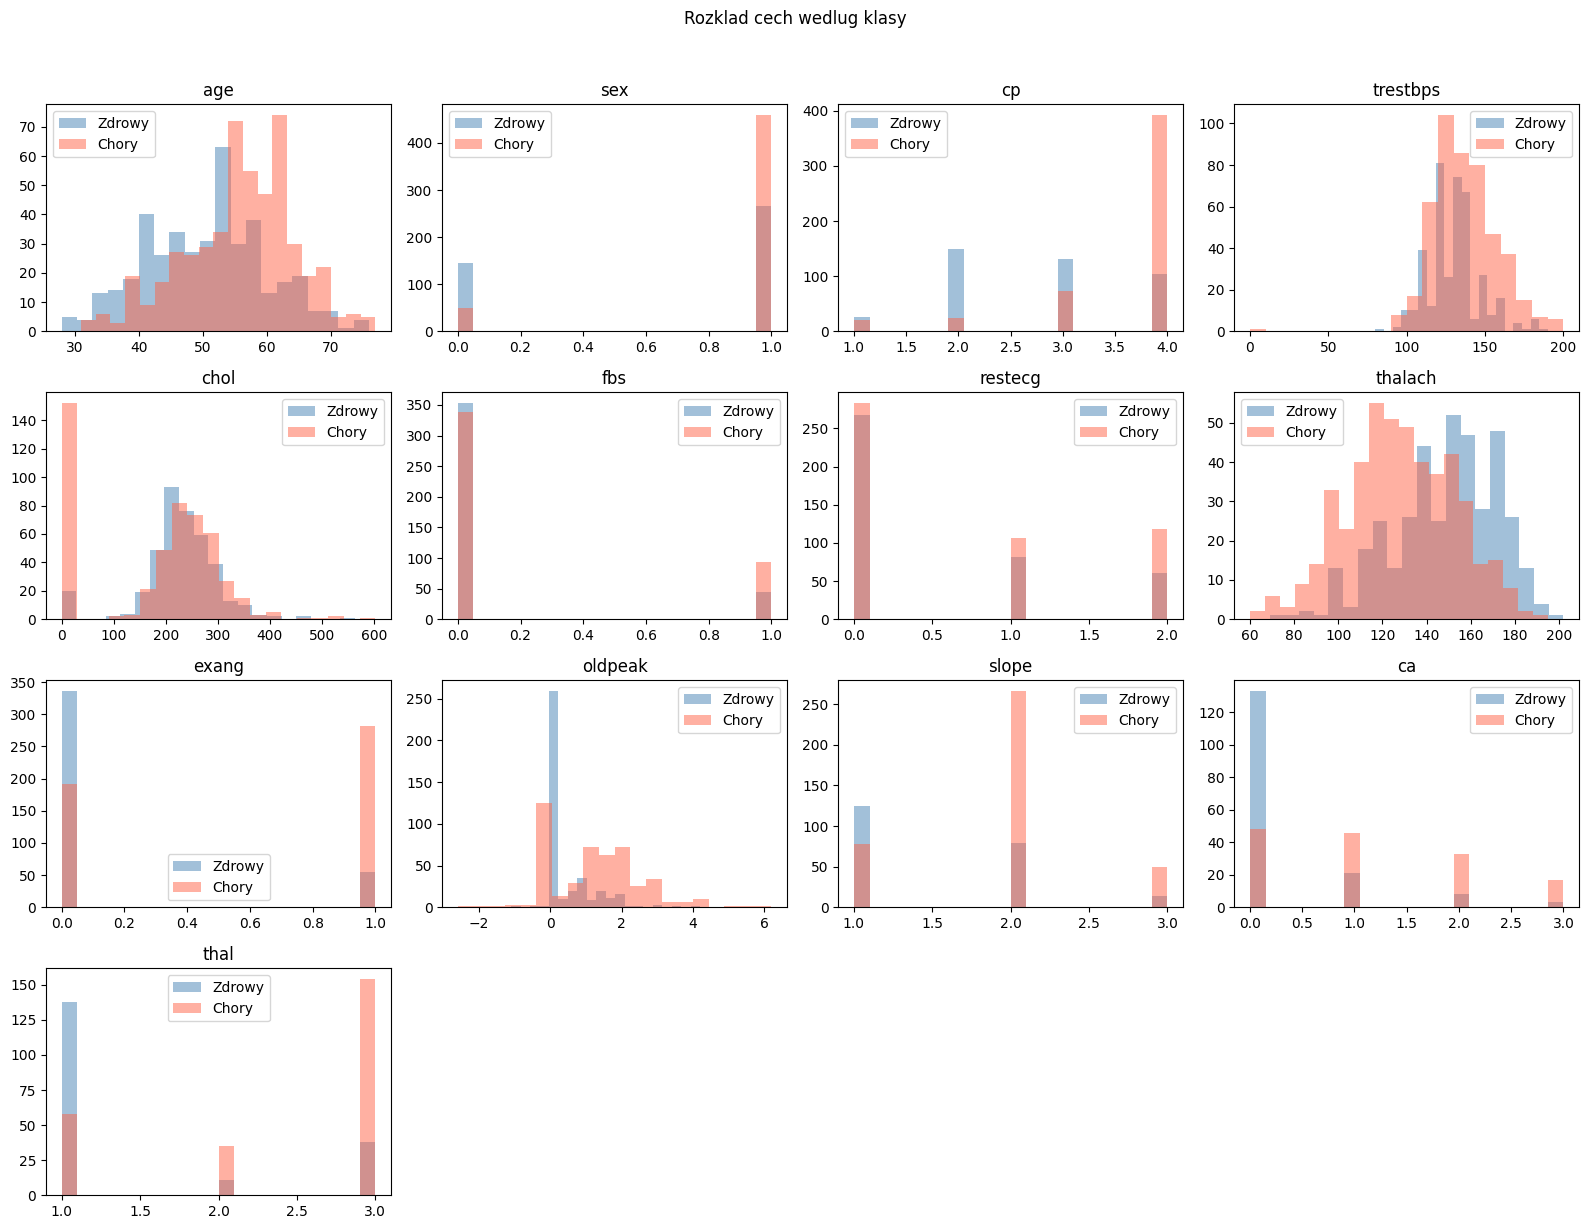

=== 4. WIEK VS MAKSYMALNE TETNO ===


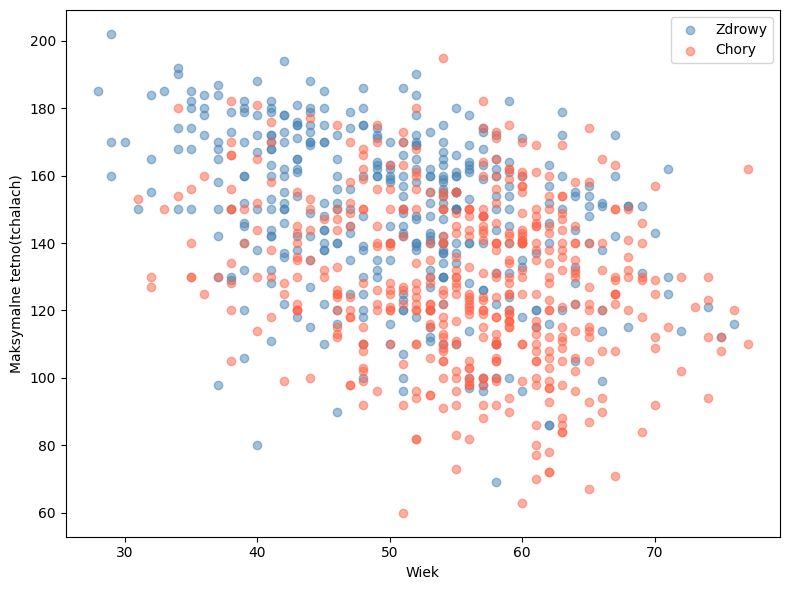

In [3]:
print("=== 1. MACIERZ KORELACJI ===")
plot_correlation_heatmap(df)

print("=== 2. ROZKLAD KLAS ===")
plot_class_distribution(df)

print("=== 3. ROZKLAD CECH WEDLUG KLAS ===")
plot_feature_distributions(df)

print("=== 4. WIEK VS MAKSYMALNE TETNO ===")
plot_scatter_age_thalach(df)

In [5]:
X_train_s, X_test_s, y_train,y_test, scaler, imputer = preprocess(df)

print(f"X_train: {X_train_s.shape}")
print(f"X_test: {X_test_s.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"\nRozklad klas w train: ")
print(y_train.value_counts(normalize = True).round(3))

print(f"\nRozklad klas w test: ")
print(y_test.value_counts(normalize = True).round(3))

print(f"\nStatystyki X_train po skalowaniu: ")
print(pd.DataFrame(X_train_s).describe().round(3))

X_train: (736, 13)
X_test: (184, 13)
y_train: (736,)
y_test: (184,)

Rozklad klas w train: 
target
1    0.553
0    0.447
Name: proportion, dtype: float64

Rozklad klas w test: 
target
1    0.554
0    0.446
Name: proportion, dtype: float64

Statystyki X_train po skalowaniu: 
            0        1        2        3        4        5        6        7   \
count  736.000  736.000  736.000  736.000  736.000  736.000  736.000  736.000   
mean     0.000    0.000    0.000    0.000    0.000   -0.000   -0.000    0.000   
std      1.001    1.001    1.001    1.001    1.001    1.001    1.001    1.001   
min     -2.734   -1.905   -2.415   -2.911   -1.858   -0.415   -0.758   -2.970   
25%     -0.704    0.525   -0.263   -0.675   -0.226   -0.415   -0.758   -0.707   
50%      0.044    0.525    0.813   -0.116    0.198   -0.415   -0.758    0.088   
75%      0.685    0.525    0.813    0.442    0.597   -0.415    0.496    0.683   
max      2.501    0.525    0.813    3.796    3.702    2.411    1.750    2.550

=== REGRESJA LOGICZNA - WYNIKI ===
Accuracy: 0.832
Precision: 0.845
Recall: 0.853
F1: 0.849
AUC-ROC: 0.895

 Confussion Matrix
 TN=66 FP=16
FN=15 TP=87

 RAPORT:
              precision    recall  f1-score   support

      Zdrowy       0.81      0.80      0.81        82
       Chory       0.84      0.85      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



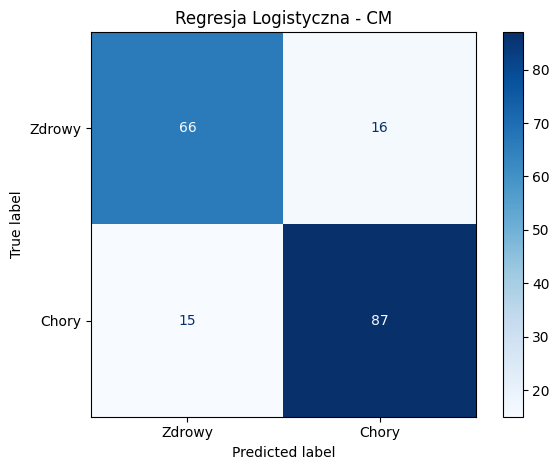

In [7]:
baseline = LogisticRegression(max_iter=1000,random_state=42)
baseline.fit(X_train_s,y_train)

baseline_results =evaluate_model(baseline,X_test_s,y_test,"Logistic Regression")

print("=== REGRESJA LOGICZNA - WYNIKI ===")
print(f"Accuracy: {baseline_results['accuracy']:.3f}")
print(f"Precision: {baseline_results['precision']:.3f}")
print(f"Recall: {baseline_results['recall']:.3f}")
print(f"F1: {baseline_results['f1']:.3f}")
print(f"AUC-ROC: {baseline_results['auc_roc']:.3f}")

print(f"\n Confussion Matrix")
cm = baseline_results['confusion_matrix']

print(f" TN={cm[0][0]} FP={cm[0][1]}")
print(f"FN={cm[1][0]} TP={cm[1][1]}")


print(f"\n RAPORT:")
print(classification_report(y_test,baseline.predict(X_test_s),
                            target_names=["Zdrowy","Chory"]))


plot_confusion_matrix(baseline,X_test_s,y_test,
                      title="Regresja Logistyczna - CM")


## 8. Wybór architektury sieci neuronowej                                                
                                                                                           
  ### 8.1 Czym jest architektura MLP?                                                      
                                                                                           
  Architektura sieci to decyzja o tym **ile warstw ukrytych** i **ile neuronów**           
  w każdej z nich. W sklearn zapisujemy to jako krotkę:
                                                                                           
  - `(32,)` — jedna warstwa ukryta z 32 neuronami                                          
  - `(64, 32)` — dwie warstwy: pierwsza 64 neurony, druga 32                               
  - `(128, 64, 32)` — trzy warstwy: 128 → 64 → 32                                          
                                                                                           
  Nie ma jednej "najlepszej" architektury — dobieramy ją eksperymentalnie                  
  i oceniamy na zbiorze walidacyjnym.                                                      
                                                                                           
  ### 8.2 Overfitting i Underfitting
                                                                                           
  **Underfitting** — model jest zbyt prosty żeby uchwycić wzorce w danych.                 
  Na krzywej uczenia: obie krzywe (train i validation) są nisko i blisko siebie.
  Rozwiązanie: więcej neuronów, więcej warstw.                                             
                  
  **Overfitting** — model zapamiętał dane treningowe zamiast się nauczyć.                  
  Na krzywej uczenia: krzywa treningowa jest wysoko, walidacyjna znacznie niżej.
  Rozwiązanie: mniej neuronów, regularyzacja, więcej danych.                               
                                                                                           
  **Optimum** — model generalizuje: obie krzywe są wysokie i blisko siebie.                
                                                                                           
  Strata                                                                                   
  │               
  │  underfit      optimum      overfit
  │  ──────────────────────────────────                                                    
  │  train ≈ val   train ≈ val  train << val
  │  oba niskie    oba wysokie  train wysoki                                               
  │                             val niski
                                                                                           
  ### 8.3 Dlaczego mniejsza sieć może być lepsza?
                                                                                           
  Na zbiorze 920 próbek sieć `(128, 64, 32)` ma znacznie więcej parametrów                 
  niż `(64, 32)`. Przy małej liczbie próbek duże sieci łatwo się przetrenowują —           
  zapamiętują szum zamiast wzorców.                                                        
                                                        

In [8]:
architectures = {
    "MLP (32,)": (32,),
    "MLP (64,32)": (64,32),
    "MLP (128,64,32)": (128,64,32),
    "MPL (64,64)": (64,64)
}


results = [baseline_results]

models = {"Logistic Regression": baseline}


for name,layers in architectures.items():
    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    )

    model.fit(X_train_s,y_train)

    result = evaluate_model(model,X_test_s,y_test,name)

    results.append(result)
    models[name] = model



results_df = pd.DataFrame(results)[["model","accuracy","precision","recall","f1","auc_roc"]]

results_df = results_df.set_index("model").round(3)

display(results_df.style.background_gradient(cmap="RdYlGn",axis=0))


print(f"\nNajlepszy Recall: {results_df['recall'].idxmax()}({results_df['recall'].max():.3f})")
print(f"Najlepszy AUC-ROC: {results_df['auc_roc'].idxmax()}({results_df['auc_roc'].max():.3f})")






,accuracy,precision,recall,f1,auc_roc
model,,,,,
Logistic Regression,0.832000,0.845000,0.853000,0.849000,0.895000
"MLP (32,)",0.821000,0.835000,0.843000,0.839000,0.888000
"MLP (64,32)",0.788000,0.789000,0.843000,0.815000,0.855000
"MLP (128,64,32)",0.821000,0.829000,0.853000,0.841000,0.854000
"MPL (64,64)",0.821000,0.800000,0.902000,0.848000,0.869000



Najlepszy Recall: MPL (64,64)(0.902)
Najlepszy AUC-ROC: Logistic Regression(0.895)
